# Predicting Diabetes Status with CDC Diabetes Health Indicators

This project predicts whether a survey respondent is in the `Diabetes_binary` positive class using the CDC Diabetes Health Indicators dataset from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/891/cdc%2Bdiabetes%2Bhealth%2Bindicators).

The prediction target is:

- `0`: no diabetes
- `1`: prediabetes or diabetes

#### Key feature groups considered include:

- Health history indicators such as high blood pressure, high cholesterol, stroke, heart disease, and difficulty walking
- Lifestyle indicators such as smoking, physical activity, fruit/vegetable consumption, and heavy alcohol consumption
- General health measures such as BMI, general health rating, physical health days, and mental health days
- Healthcare access variables such as health coverage and cost barriers to seeing a doctor
- Demographic and socioeconomic variables such as sex, age group, education level, and income group

#### The project follows a structured ML pipeline:

- [1. Data Loading](#1)
- [2. Exploratory Data Analysis](#2)
- [3. Train/Test Split](#3)
- [4. Feature Engineering](#4)
- [5. Classification Modeling](#5)
- [6. Hyperparameter Tuning](#6)
- [7. Selecting the Best Model](#7)
- [8. Model Interpretation](#8)
- [9. Results](#9)
- [10. Save Model](#10)

Because this is a health-related classification problem, accuracy alone is not enough. We will pay special attention to recall, precision, ROC-AUC, and average precision because the positive class is much smaller than the negative class.

* * *


In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore", category=ConvergenceWarning)

RANDOM_STATE = 42

# 1. Data Loading <a id="1"></a>

The dataset is fetched through `ucimlrepo`, which keeps the notebook reproducible without storing a local CSV file in the repository.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

In [3]:
# Fetch dataset from the UCI Machine Learning Repository.
cdc_diabetes = fetch_ucirepo(id=891)

X_raw = cdc_diabetes.data.features.copy()
y_raw = cdc_diabetes.data.targets.copy()

df = pd.concat([X_raw, y_raw], axis=1)
df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,0,1,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,0,0,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,0,1,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,0,1,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,0,1,0,2,3,0,0,0,11,5,4,0


In [4]:
print(f"Dataset name: {cdc_diabetes.metadata.name}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Feature columns: {X_raw.shape[1]}")
print(f"Target columns: {y_raw.shape[1]}")
print(f"Target: {list(y_raw.columns)}")

Dataset name: CDC Diabetes Health Indicators
Rows: 253,680
Columns: 22
Feature columns: 21
Target columns: 1
Target: ['Diabetes_binary']


#### Data dictionary

| Name | Role | Description |
|:--|:--|:--|
| `Diabetes_binary` | Target | 0 = no diabetes, 1 = prediabetes or diabetes |
| `HighBP` | Feature | 0 = no high blood pressure, 1 = high blood pressure |
| `HighChol` | Feature | 0 = no high cholesterol, 1 = high cholesterol |
| `CholCheck` | Feature | 0 = no cholesterol check in 5 years, 1 = cholesterol check in 5 years |
| `BMI` | Feature | Body Mass Index |
| `Smoker` | Feature | 0 = has not smoked at least 100 cigarettes, 1 = has smoked at least 100 cigarettes |
| `Stroke` | Feature | 0 = no stroke history, 1 = has had a stroke |
| `HeartDiseaseorAttack` | Feature | 0 = no coronary heart disease or myocardial infarction, 1 = yes |
| `PhysActivity` | Feature | 0 = no physical activity in past 30 days outside work, 1 = yes |
| `Fruits` | Feature | 0 = consumes fruit less than once per day, 1 = one or more times per day |
| `Veggies` | Feature | 0 = consumes vegetables less than once per day, 1 = one or more times per day |
| `HvyAlcoholConsump` | Feature | 0 = not a heavy alcohol consumer, 1 = heavy alcohol consumer |
| `AnyHealthcare` | Feature | 0 = no health care coverage, 1 = has coverage |
| `NoDocbcCost` | Feature | 0 = cost did not prevent a doctor visit, 1 = cost prevented a needed doctor visit |
| `GenHlth` | Feature | General health rating from 1 = excellent to 5 = poor |
| `MentHlth` | Feature | Number of days in the past 30 where mental health was not good |
| `PhysHlth` | Feature | Number of days in the past 30 where physical health was not good |
| `DiffWalk` | Feature | 0 = no serious difficulty walking/climbing stairs, 1 = yes |
| `Sex` | Feature | 0 = female, 1 = male |
| `Age` | Feature | 13-level age category, from 1 = 18-24 to 13 = 80 or older |
| `Education` | Feature | Education level from 1 = never attended/kindergarten to 6 = college graduate |
| `Income` | Feature | Income category from 1 = less than $\$$10,000 to 8 = $\$$75,000 or more |


The UCI page reports no missing values. We will verify this in the loaded data before modeling.

The feature table does not include the respondent ID. Because of that, identical rows can represent different people with the same survey answers, so we will not drop duplicate feature rows automatically.


In [5]:
missing_values = df.isna().sum().to_frame("missing_values")
missing_values[missing_values["missing_values"] > 0]

,missing_values


In [6]:
print(f"Total missing values: {df.isna().sum().sum():,}")
print(f"Duplicate rows after removing ID from the data: {df.duplicated().sum():,}")

Total missing values: 0
Duplicate rows after removing ID from the data: 24,206


# 2. Exploratory Data Analysis <a id="2"></a>

The goal of EDA is to understand the target distribution, feature ranges, and relationships between predictors and diabetes status before building models.


In [7]:
print("Number of rows and columns in the dataset:")
print(df.shape)

Number of rows and columns in the dataset:
(253680, 22)


In [8]:
print("Descriptive statistics for all numeric variables:")
df.describe().T

Descriptive statistics for all numeric variables:


,count,mean,std,min,25%,50%,75%,max
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0
Veggies,253680.0,0.811420,0.391175,0.0,1.0,1.0,1.0,1.0


In [9]:
target_col = "Diabetes_binary"

target_distribution = (
    df[target_col]
    .value_counts()
    .rename(index={0: "No diabetes", 1: "Prediabetes/diabetes"})
    .to_frame("count")
)
target_distribution["percentage"] = (target_distribution["count"] / len(df) * 100).round(2)
target_distribution

,count,percentage
Diabetes_binary,,
No diabetes,218334,86.07
Prediabetes/diabetes,35346,13.93


The target variable is imbalanced: the positive class is much smaller than the negative class. This means a model can look accurate by mostly predicting `0`, so we will use metrics that focus on the minority class too.


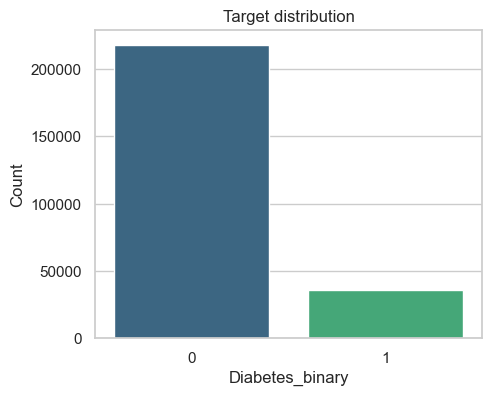

In [10]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x=target_col, palette="viridis")
plt.title("Target distribution")
plt.xlabel("Diabetes_binary")
plt.ylabel("Count")
plt.show()

In [11]:
correlation_with_target = (
    df.drop(columns=[target_col])
    .corrwith(df[target_col])
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .to_frame("correlation_with_diabetes")
)
correlation_with_target.head(12)

,correlation_with_diabetes
GenHlth,0.293569
HighBP,0.263129
DiffWalk,0.218344
BMI,0.216843
HighChol,0.200276
Age,0.177442
HeartDiseaseorAttack,0.177282
PhysHlth,0.171337
Income,-0.163919
Education,-0.124456


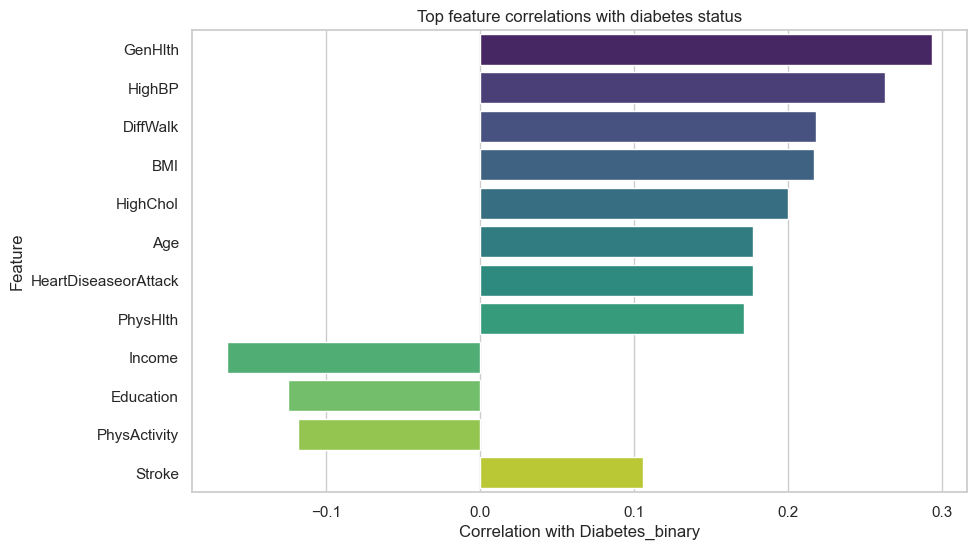

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=correlation_with_target.head(12).reset_index(),
    x="correlation_with_diabetes",
    y="index",
    palette="viridis",
)
plt.title("Top feature correlations with diabetes status")
plt.xlabel("Correlation with Diabetes_binary")
plt.ylabel("Feature")
plt.show()

Correlation is not causation, but it is useful for quickly seeing which features move most strongly with the target. In this dataset, diabetes status is often related to health history, general health, age, BMI, and mobility-related indicators.


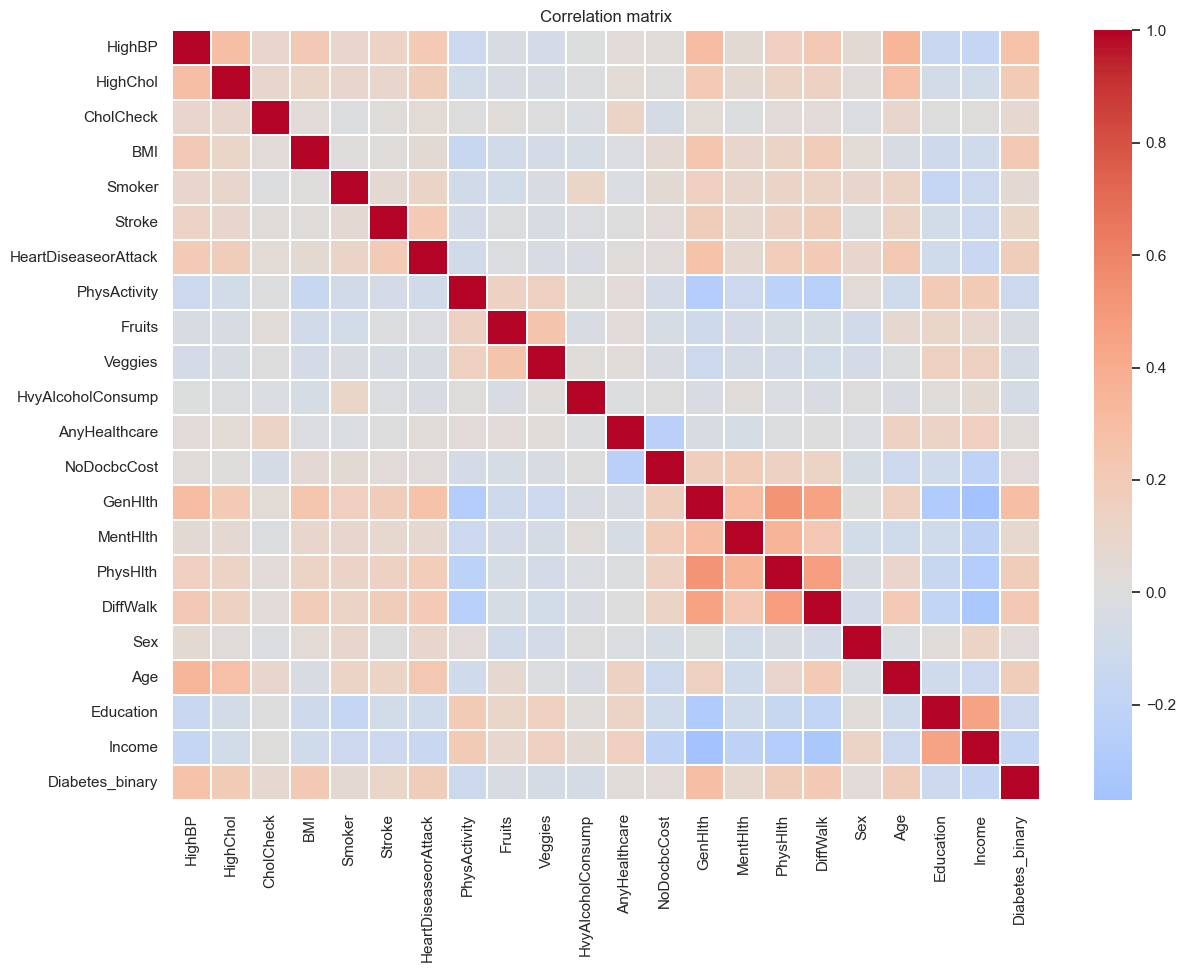

In [13]:
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Correlation matrix")
plt.show()

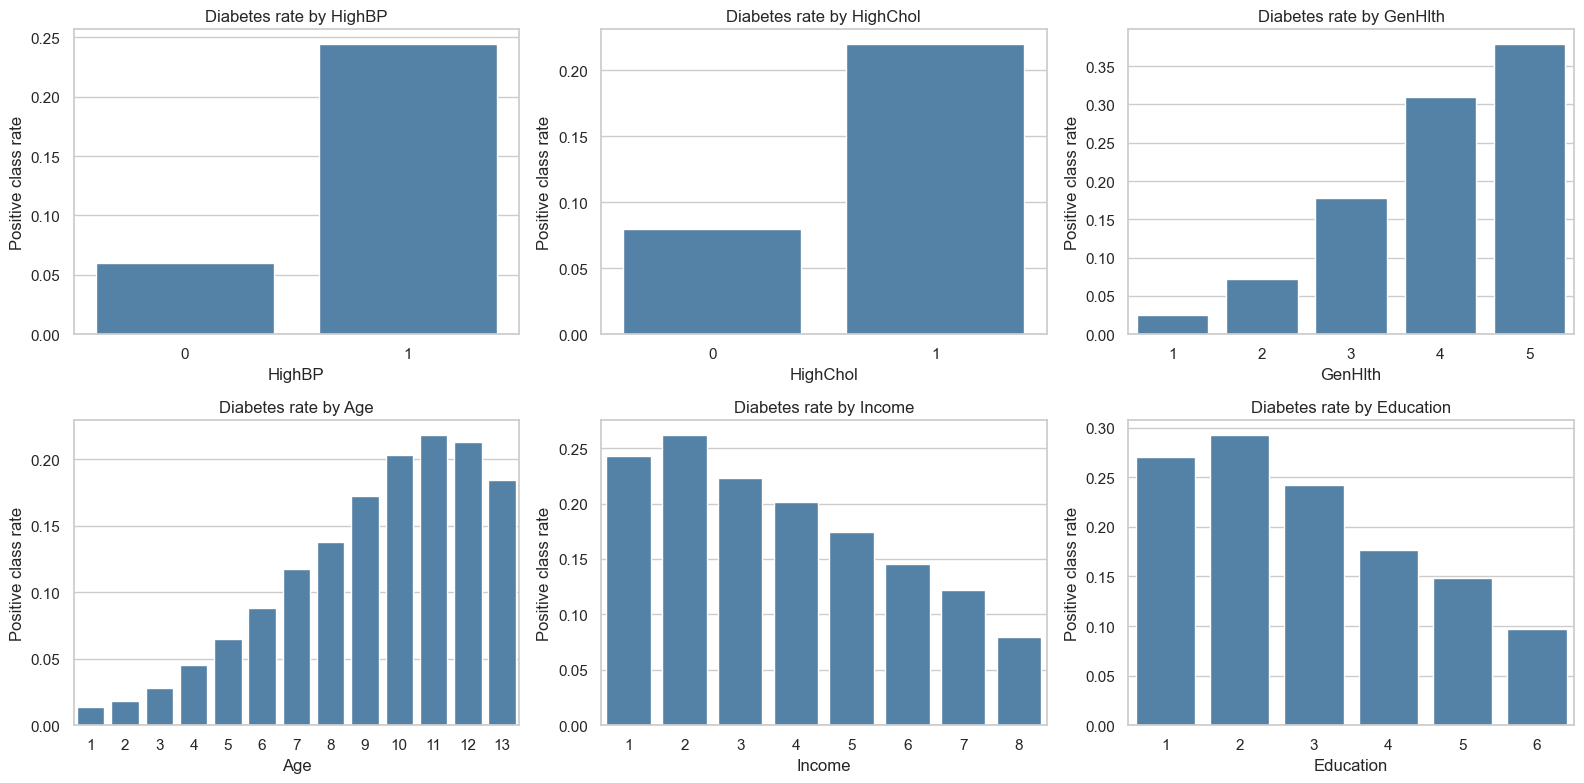

In [14]:
features_to_plot = ["HighBP", "HighChol", "GenHlth", "Age", "Income", "Education"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, feature in zip(axes.ravel(), features_to_plot):
    rate_df = df.groupby(feature)[target_col].mean().reset_index()
    sns.barplot(data=rate_df, x=feature, y=target_col, ax=ax, color="steelblue")
    ax.set_title(f"Diabetes rate by {feature}")
    ax.set_ylabel("Positive class rate")

plt.tight_layout()
plt.show()

#### Pairplot of selected predictors

The full dataset is large, so this pairplot uses a reproducible sample. The hue colors each point by `Diabetes_binary`, which helps show whether the positive class separates cleanly across common health and demographic predictors.

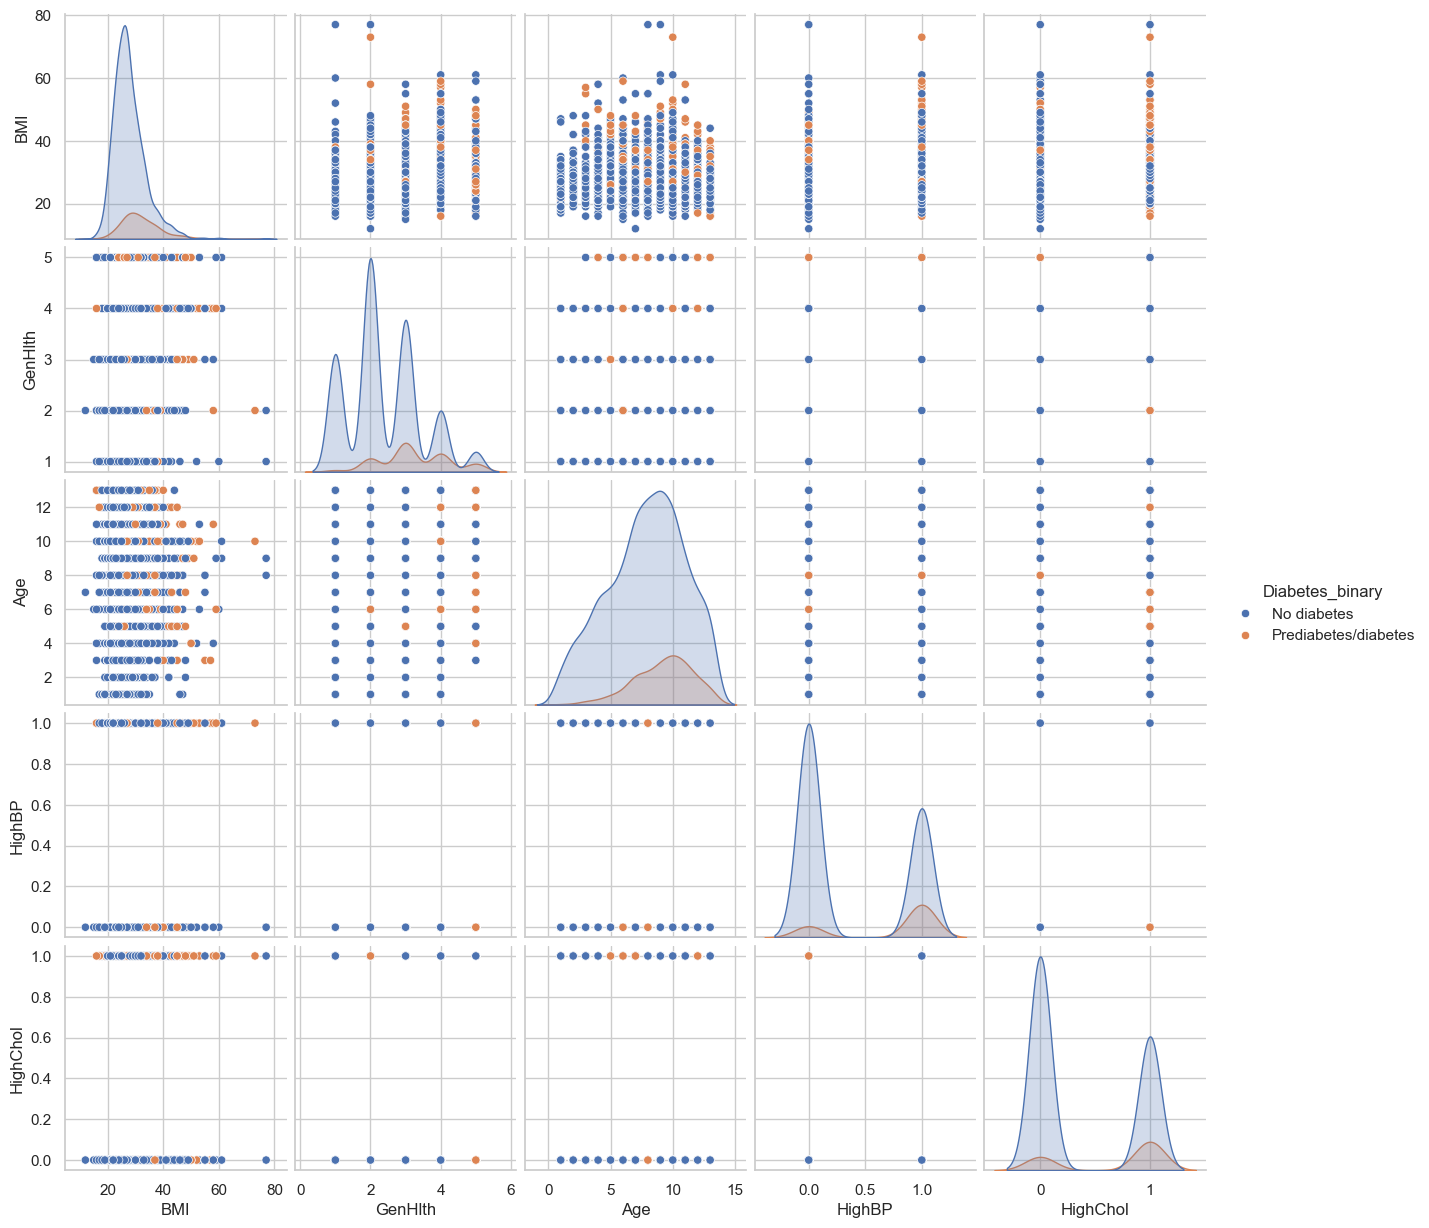

In [39]:
pairplot_features = ["BMI", "GenHlth", "Age", "HighBP", "HighChol"]

pairplot_sample = df[pairplot_features + [target_col]].sample(
    n=min(3_000, len(df)),
    random_state=RANDOM_STATE,
).copy()
pairplot_sample[target_col] = pairplot_sample[target_col].map(
    {0: "No diabetes", 1: "Prediabetes/diabetes"}
)

sns.pairplot(pairplot_sample, hue=target_col)
plt.show()

#### EDA notes

- Diabetes status is imbalanced, so the baseline accuracy can be misleading.
- `HighBP`, `HighChol`, `BMI`, `GenHlth`, `Age`, and `DiffWalk` are expected to be important because they directly describe health status or risk factors.
- `Sex`, `Age`, `Education`, and `Income` are sensitive or demographic variables. We will keep them in the main model for now, but we will also inspect subgroup performance later so model quality is not summarized by a single global score.
- The sampled pairplot helps show that the classes overlap across the selected predictors, so we should expect useful risk ranking rather than perfectly separated groups.


# 3. Train/Test Split <a id="3"></a>

We split the data before feature engineering so the test set remains a realistic holdout. Because the target is imbalanced, the split is stratified to preserve the positive-class rate in both sets.


In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Training set size: {X_train.shape}. Training labels size: {y_train.shape}")
print(f"Test set size: {X_test.shape}. Test labels size: {y_test.shape}")
print("Training positive-class rate:", round(y_train.mean(), 4))
print("Test positive-class rate:", round(y_test.mean(), 4))

Training set size: (202944, 21). Training labels size: (202944,)
Test set size: (50736, 21). Test labels size: (50736,)
Training positive-class rate: 0.1393
Test positive-class rate: 0.1393


# 4. Feature Engineering <a id="4"></a>

All columns are already numeric. We will still define feature groups so preprocessing is explicit:

- Binary features are passed through unchanged.
- Continuous and ordinal features are standardized for models such as logistic regression.
- Tree-based models are not sensitive to scaling, but using the same preprocessing pipeline keeps the workflow consistent.

For the SMOTENC experiment later, the binary and ordinal survey fields are treated as categorical so synthetic samples do not create impossible fractional categories.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

binary_features = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex",
]

continuous_features = ["BMI", "MentHlth", "PhysHlth"]
ordinal_features = ["GenHlth", "Age", "Education", "Income"]

all_grouped_features = binary_features + continuous_features + ordinal_features
missing_from_groups = sorted(set(X_train.columns) - set(all_grouped_features))
extra_in_groups = sorted(set(all_grouped_features) - set(X_train.columns))

smotenc_categorical_features = ordinal_features + binary_features
smotenc_categorical_feature_indices = [
    X_train.columns.get_loc(column) for column in smotenc_categorical_features
]

print("Features missing from groups:", missing_from_groups)
print("Extra grouped features not in X_train:", extra_in_groups)
print("SMOTENC categorical features:", smotenc_categorical_features)

Features missing from groups: []
Extra grouped features not in X_train: []
SMOTENC categorical features: ['GenHlth', 'Age', 'Education', 'Income', 'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']


In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ("scaled", StandardScaler(), continuous_features + ordinal_features),
        ("binary", "passthrough", binary_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

preprocessor.set_output(transform="pandas")

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.head()

,BMI,MentHlth,PhysHlth,GenHlth,Age,Education,Income,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex
153147,-0.057282,-0.430031,-0.487165,-0.479079,-1.977081,-1.064421,-0.506998,0,0,1,1,0,0,1,1,1,0,1,0,0,1
176137,-0.815055,-0.430031,-0.487165,-0.479079,1.627845,-1.064421,0.457948,1,0,1,1,0,0,1,1,1,0,1,0,0,1
175578,0.094273,-0.430031,-0.487165,-1.415079,0.316963,0.963192,0.940421,1,1,1,0,0,0,1,1,1,0,1,0,0,1
177887,1.609820,-0.430031,-0.487165,1.392923,-0.338479,-1.064421,0.457948,1,1,1,0,0,0,0,0,0,0,1,0,0,1
182143,-1.875938,3.614406,2.950984,2.328923,-0.338479,-0.050614,-2.436889,0,1,1,1,0,0,1,1,1,0,1,1,1,0


# 5. Classification Modeling <a id="5"></a>

We will start with a baseline and then compare several classification models. Since the positive class is relatively rare, we will evaluate each model with multiple metrics:

- `Accuracy`: overall percentage of correct predictions
- `Precision`: among predicted positives, how many were actually positive
- `Recall`: among actual positives, how many were found
- `F1`: balance between precision and recall
- `ROC AUC`: ranking quality across thresholds
- `Average Precision`: precision-recall performance, useful for imbalanced data

The model comparison includes the original scikit-learn models plus XGBoost, LightGBM, and CatBoost. We also test SMOTENC on the boosted-tree models as a separate training strategy. SMOTENC is applied only to training folds inside the pipeline, so the validation/test data remain untouched.

In [18]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


def evaluate_predictions(y_true, y_pred, y_score=None):
    """Return a compact dictionary of classification metrics."""
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        metrics["ROC AUC"] = roc_auc_score(y_true, y_score)
        metrics["Average Precision"] = average_precision_score(y_true, y_score)
    return metrics


majority_class = y_train.mode()[0]
y_baseline_pred = np.full(shape=y_test.shape, fill_value=majority_class)
y_baseline_score = np.full(shape=y_test.shape, fill_value=y_train.mean(), dtype=float)

baseline_metrics = evaluate_predictions(y_test, y_baseline_pred, y_baseline_score)
pd.DataFrame([baseline_metrics], index=["Majority class baseline"])

,Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
Majority class baseline,0.860671,0.0,0.0,0.0,0.5,0.139329


The baseline predicts the majority class for everyone. It should have high accuracy but zero recall for the positive class, which is why it is not clinically useful by itself.


In [19]:
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from lightgbm import LGBMClassifier
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier


class CatBoostSklearnClassifier(ClassifierMixin, BaseEstimator):
    """Small compatibility wrapper for CatBoost inside sklearn 1.8 pipelines."""

    def __init__(
        self,
        iterations=150,
        learning_rate=0.05,
        depth=4,
        auto_class_weights=None,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
    ):
        self.iterations = iterations
        self.learning_rate = learning_rate
        self.depth = depth
        self.auto_class_weights = auto_class_weights
        self.loss_function = loss_function
        self.eval_metric = eval_metric
        self.random_seed = random_seed
        self.verbose = verbose
        self.allow_writing_files = allow_writing_files

    def fit(self, X, y):
        params = {
            "iterations": self.iterations,
            "learning_rate": self.learning_rate,
            "depth": self.depth,
            "loss_function": self.loss_function,
            "eval_metric": self.eval_metric,
            "random_seed": self.random_seed,
            "verbose": self.verbose,
            "allow_writing_files": self.allow_writing_files,
        }
        if self.auto_class_weights is not None:
            params["auto_class_weights"] = self.auto_class_weights

        self.model_ = CatBoostClassifier(**params)
        self.model_.fit(X, y)
        self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        return self.model_.predict(X).astype(int).ravel()

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


negative_count, positive_count = np.bincount(y_train)
scale_pos_weight = negative_count / positive_count

class_weighted_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.06,
        max_leaf_nodes=31,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ),
    "CatBoost": CatBoostSklearnClassifier(
        iterations=150,
        learning_rate=0.05,
        depth=4,
        auto_class_weights="Balanced",
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
    ),
}

smotenc_models = {
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.06,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ),
    "CatBoost": CatBoostSklearnClassifier(
        iterations=150,
        learning_rate=0.05,
        depth=4,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
    ),
}

model_candidates = []
for model_name, model in class_weighted_models.items():
    model_candidates.append(
        {
            "Candidate": f"{model_name} (Class weights)",
            "Model": model_name,
            "Training Strategy": "Class weights",
            "Estimator": model,
            "Use SMOTENC": False,
        }
    )

for model_name, model in smotenc_models.items():
    model_candidates.append(
        {
            "Candidate": f"{model_name} (SMOTENC)",
            "Model": model_name,
            "Training Strategy": "SMOTENC",
            "Estimator": model,
            "Use SMOTENC": True,
        }
    )

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def make_model_pipeline(model, use_smotenc=False):
    estimator = clone(model)
    if use_smotenc:
        return ImbPipeline(
            steps=[
                (
                    "resampler",
                    SMOTENC(
                        categorical_features=smotenc_categorical_feature_indices,
                        sampling_strategy=0.5,
                        random_state=RANDOM_STATE,
                    ),
                ),
                ("preprocessor", preprocessor),
                ("model", estimator),
            ]
        )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )

pd.DataFrame(model_candidates).drop(columns="Estimator")

,Candidate,Model,Training Strategy,Use SMOTENC
0,Logistic Regression (Class weights),Logistic Regression,Class weights,False
1,Decision Tree (Class weights),Decision Tree,Class weights,False
2,Random Forest (Class weights),Random Forest,Class weights,False
3,Hist Gradient Boosting (Class weights),Hist Gradient Boosting,Class weights,False
4,XGBoost (Class weights),XGBoost,Class weights,False
5,LightGBM (Class weights),LightGBM,Class weights,False
6,CatBoost (Class weights),CatBoost,Class weights,False
7,Hist Gradient Boosting (SMOTENC),Hist Gradient Boosting,SMOTENC,True
8,XGBoost (SMOTENC),XGBoost,SMOTENC,True
9,LightGBM (SMOTENC),LightGBM,SMOTENC,True


To keep the notebook responsive on a standard laptop, cross-validation is run on a stratified sample of the training data. The final selected model is still fit on the full training set later.

The expanded model list can take a few minutes because it includes XGBoost, LightGBM, CatBoost, and SMOTENC variants. If you want full-data cross-validation, set `CV_SAMPLE_SIZE = None`. If you want a faster development run, lower `CV_SAMPLE_SIZE`.

In [20]:
CV_SAMPLE_SIZE = 60_000

if CV_SAMPLE_SIZE is not None and len(X_train) > CV_SAMPLE_SIZE:
    X_cv, _, y_cv, _ = train_test_split(
        X_train,
        y_train,
        train_size=CV_SAMPLE_SIZE,
        stratify=y_train,
        random_state=RANDOM_STATE,
    )
else:
    X_cv, y_cv = X_train, y_train

print(f"Cross-validation rows: {len(X_cv):,}")
print("Cross-validation positive-class rate:", round(y_cv.mean(), 4))

Cross-validation rows: 60,000
Cross-validation positive-class rate: 0.1393


In [21]:
cv_results = []

for candidate in model_candidates:
    pipeline = make_model_pipeline(
        candidate["Estimator"],
        use_smotenc=candidate["Use SMOTENC"],
    )
    scores = cross_validate(
        pipeline,
        X_cv,
        y_cv,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )
    row = {
        "Candidate": candidate["Candidate"],
        "Model": candidate["Model"],
        "Training Strategy": candidate["Training Strategy"],
    }
    for metric_name in scoring:
        row[f"{metric_name}_mean"] = scores[f"test_{metric_name}"].mean()
        row[f"{metric_name}_std"] = scores[f"test_{metric_name}"].std()
    cv_results.append(row)

cv_results_df = pd.DataFrame(cv_results).sort_values(
    ["average_precision_mean", "roc_auc_mean", "f1_mean"],
    ascending=False,
).reset_index(drop=True)

cv_results_df.insert(0, "Rank", range(1, len(cv_results_df) + 1))
cv_results_df

,Rank,Candidate,Model,Training Strategy,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
0,1,XGBoost (Class weights),XGBoost,Class weights,0.725100,0.001901,0.309920,0.002401,0.793182,0.006424,0.445692,0.003397,0.830183,0.002931,0.434546,0.007381
1,2,LightGBM (Class weights),LightGBM,Class weights,0.729483,0.003000,0.311546,0.003127,0.778110,0.004003,0.444938,0.003727,0.827660,0.003035,0.433939,0.006227
2,3,Hist Gradient Boosting (Class weights),Hist Gradient Boosting,Class weights,0.725733,0.003473,0.309617,0.003413,0.787321,0.007730,0.444441,0.004234,0.828402,0.003324,0.433221,0.006501
3,4,CatBoost (Class weights),CatBoost,Class weights,0.724650,0.002241,0.309998,0.002325,0.796292,0.003775,0.446262,0.002869,0.830113,0.003091,0.431455,0.006709
4,5,CatBoost (SMOTENC),CatBoost,SMOTENC,0.813917,0.000325,0.384094,0.001064,0.555981,0.006302,0.454314,0.002746,0.820959,0.002252,0.413546,0.006439
5,6,XGBoost (SMOTENC),XGBoost,SMOTENC,0.812533,0.001069,0.381565,0.001808,0.556459,0.008293,0.452684,0.003241,0.819127,0.001478,0.413337,0.004502
6,7,Random Forest (Class weights),Random Forest,Class weights,0.777917,0.002247,0.346790,0.002943,0.672010,0.003438,0.457484,0.002868,0.822259,0.002589,0.410875,0.007085
7,8,Logistic Regression (Class weights),Logistic Regression,Class weights,0.733733,0.001340,0.313572,0.001780,0.766148,0.004109,0.445009,0.002441,0.823425,0.003335,0.407277,0.012373
8,9,LightGBM (SMOTENC),LightGBM,SMOTENC,0.812950,0.001351,0.379086,0.003930,0.536962,0.009444,0.444409,0.005776,0.814655,0.001100,0.405900,0.002502
9,10,Hist Gradient Boosting (SMOTENC),Hist Gradient Boosting,SMOTENC,0.813017,0.001951,0.378234,0.005591,0.531340,0.012067,0.441888,0.007829,0.813171,0.001792,0.405168,0.003992


Average precision is emphasized because it measures performance on the positive class in an imbalanced classification setting. ROC-AUC is still useful, but it can look strong even when the minority class is difficult to identify at a practical threshold.

In [22]:
def positive_class_scores(estimator, X_values):
    """Return scores/probabilities for the positive class."""
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X_values)[:, 1]
    return estimator.decision_function(X_values)


trained_models = {}
test_results = []

for candidate in model_candidates:
    pipeline = make_model_pipeline(
        candidate["Estimator"],
        use_smotenc=candidate["Use SMOTENC"],
    )
    pipeline.fit(X_train, y_train)
    trained_models[candidate["Candidate"]] = pipeline

    y_pred = pipeline.predict(X_test)
    y_score = positive_class_scores(pipeline, X_test)
    row = {
        "Candidate": candidate["Candidate"],
        "Model": candidate["Model"],
        "Training Strategy": candidate["Training Strategy"],
    }
    row.update(evaluate_predictions(y_test, y_pred, y_score))
    test_results.append(row)

test_results_df = pd.DataFrame(test_results).sort_values(
    ["Average Precision", "ROC AUC", "F1"],
    ascending=False,
).reset_index(drop=True)

test_results_df.insert(0, "Rank", range(1, len(test_results_df) + 1))
test_results_df

,Rank,Candidate,Model,Training Strategy,Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
0,1,LightGBM (Class weights),LightGBM,Class weights,0.720475,0.305857,0.792616,0.441390,0.827276,0.424244
1,2,Hist Gradient Boosting (Class weights),Hist Gradient Boosting,Class weights,0.719923,0.305602,0.794030,0.441343,0.827006,0.423070
2,3,XGBoost (Class weights),XGBoost,Class weights,0.719864,0.305383,0.792899,0.440939,0.826254,0.420487
3,4,CatBoost (Class weights),CatBoost,Class weights,0.720514,0.305530,0.790211,0.440675,0.825424,0.417901
4,5,Random Forest (Class weights),Random Forest,Class weights,0.746275,0.321613,0.740133,0.448387,0.822673,0.414181
5,6,XGBoost (SMOTENC),XGBoost,SMOTENC,0.815043,0.387523,0.564153,0.459447,0.818765,0.409948
6,7,CatBoost (SMOTENC),CatBoost,SMOTENC,0.814747,0.386097,0.558636,0.456611,0.819992,0.409109
7,8,LightGBM (SMOTENC),LightGBM,SMOTENC,0.813840,0.383324,0.552129,0.452496,0.816918,0.403330
8,9,Hist Gradient Boosting (SMOTENC),Hist Gradient Boosting,SMOTENC,0.814195,0.383105,0.546612,0.450481,0.816078,0.401408
9,10,Decision Tree (Class weights),Decision Tree,Class weights,0.705554,0.292764,0.786391,0.426680,0.813441,0.393367


# 6. Hyperparameter Tuning <a id="6"></a>

The initial model comparison gives a good starting point. Since we now have several model families and training strategies, tuning only one model would be too narrow.

We will tune the top three candidates from cross-validation, ranked by average precision. This keeps the search focused on promising models while avoiding an expensive exhaustive search across every possible candidate.

The tuning searches are ranked by average precision, but we also display accuracy, precision, recall, F1, ROC-AUC, and average precision so the tradeoffs remain visible.

In [23]:
from sklearn.model_selection import ParameterGrid, RandomizedSearchCV

TUNING_CANDIDATE_COUNT = 3
TUNING_ITERATIONS = 12

top_candidates_to_tune = cv_results_df.head(TUNING_CANDIDATE_COUNT)["Candidate"].tolist()
candidate_lookup = {candidate["Candidate"]: candidate for candidate in model_candidates}

print("Candidates selected for hyperparameter tuning:")
for candidate_name in top_candidates_to_tune:
    print("-", candidate_name)


def tuning_param_distributions(candidate):
    """Return a focused parameter search space for a model candidate."""
    model_name = candidate["Model"]
    use_smotenc = candidate["Use SMOTENC"]

    if model_name == "Logistic Regression":
        params = {
            "model__C": [0.25, 0.5, 1.0, 2.0, 4.0],
        }
    elif model_name == "Decision Tree":
        params = {
            "model__max_depth": [4, 6, 8, 10, 12],
            "model__min_samples_leaf": [25, 50, 100, 200],
            "model__min_samples_split": [50, 100, 200, 400],
        }
    elif model_name == "Random Forest":
        params = {
            "model__n_estimators": [150, 250, 400],
            "model__max_depth": [8, 12, 16, None],
            "model__min_samples_leaf": [10, 25, 50],
            "model__max_features": ["sqrt", 0.75, 1.0],
        }
    elif model_name == "Hist Gradient Boosting":
        params = {
            "model__learning_rate": [0.03, 0.05, 0.08, 0.10],
            "model__max_iter": [100, 200, 300],
            "model__max_leaf_nodes": [15, 31, 63],
            "model__l2_regularization": [0.0, 0.1, 1.0],
        }
    elif model_name == "XGBoost":
        params = {
            "model__n_estimators": [150, 250, 400],
            "model__learning_rate": [0.03, 0.05, 0.08, 0.10],
            "model__max_depth": [2, 3, 4, 5],
            "model__min_child_weight": [1, 5, 10],
            "model__subsample": [0.8, 0.9, 1.0],
            "model__colsample_bytree": [0.8, 0.9, 1.0],
            "model__reg_lambda": [1, 5, 10],
        }
    elif model_name == "LightGBM":
        params = {
            "model__n_estimators": [150, 250, 400],
            "model__learning_rate": [0.03, 0.05, 0.08, 0.10],
            "model__num_leaves": [15, 31, 63],
            "model__min_child_samples": [20, 50, 100],
            "model__subsample": [0.8, 0.9, 1.0],
            "model__colsample_bytree": [0.8, 0.9, 1.0],
            "model__reg_lambda": [0, 1, 5],
        }
    elif model_name == "CatBoost":
        params = {
            "model__iterations": [100, 150, 250, 350],
            "model__learning_rate": [0.03, 0.05, 0.08, 0.10],
            "model__depth": [3, 4, 5, 6],
        }
    else:
        raise ValueError(f"No tuning grid defined for {model_name}")

    if use_smotenc:
        params["resampler__sampling_strategy"] = [0.35, 0.5, 0.75, 1.0]

    return params


tuning_searches = {}
tuning_summary = []
tuning_cv_results = []

for candidate_name in top_candidates_to_tune:
    candidate = candidate_lookup[candidate_name]
    pipeline = make_model_pipeline(
        candidate["Estimator"],
        use_smotenc=candidate["Use SMOTENC"],
    )
    param_distributions = tuning_param_distributions(candidate)

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=min(TUNING_ITERATIONS, len(ParameterGrid(param_distributions))),
        scoring=scoring,
        refit="average_precision",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=1,
    )
    search.fit(X_cv, y_cv)
    tuning_searches[candidate_name] = search

    search_results = pd.DataFrame(search.cv_results_)
    search_results["Candidate"] = candidate_name
    search_results["Tuned Candidate"] = f"Tuned {candidate_name}"
    tuning_cv_results.append(search_results)

    best_row = search_results.loc[search.best_index_]
    tuning_summary.append(
        {
            "Candidate": candidate_name,
            "Tuned Candidate": f"Tuned {candidate_name}",
            "mean_average_precision": best_row["mean_test_average_precision"],
            "std_average_precision": best_row["std_test_average_precision"],
            "mean_roc_auc": best_row["mean_test_roc_auc"],
            "mean_f1": best_row["mean_test_f1"],
            "mean_recall": best_row["mean_test_recall"],
            "mean_precision": best_row["mean_test_precision"],
            "mean_accuracy": best_row["mean_test_accuracy"],
            "best_params": search.best_params_,
        }
    )

tuning_summary_df = pd.DataFrame(tuning_summary).sort_values(
    ["mean_average_precision", "mean_roc_auc", "mean_f1"],
    ascending=False,
).reset_index(drop=True)

tuning_summary_df

Candidates selected for hyperparameter tuning:
- XGBoost (Class weights)
- LightGBM (Class weights)
- Hist Gradient Boosting (Class weights)
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits


,Candidate,Tuned Candidate,mean_average_precision,std_average_precision,mean_roc_auc,mean_f1,mean_recall,mean_precision,mean_accuracy,best_params
0,LightGBM (Class weights),Tuned LightGBM (Class weights),0.435634,0.006761,0.829106,0.445057,0.785885,0.310431,0.726917,"{'model__subsample': 0.9, 'model__reg_lambda':..."
1,XGBoost (Class weights),Tuned XGBoost (Class weights),0.435607,0.007509,0.829997,0.446207,0.789474,0.310990,0.726950,"{'model__subsample': 1.0, 'model__reg_lambda':..."
2,Hist Gradient Boosting (Class weights),Tuned Hist Gradient Boosting (Class weights),0.433463,0.005972,0.829233,0.443939,0.791746,0.308452,0.723633,"{'model__max_leaf_nodes': 15, 'model__max_iter..."


In [24]:
tuning_cv_results_df = pd.concat(tuning_cv_results, ignore_index=True)

tuning_results_display = (
    tuning_cv_results_df
    .sort_values(["mean_test_average_precision", "mean_test_roc_auc", "mean_test_f1"], ascending=False)
    .head(15)
    [[
        "Candidate",
        "Tuned Candidate",
        "mean_test_average_precision",
        "std_test_average_precision",
        "mean_test_roc_auc",
        "mean_test_f1",
        "mean_test_recall",
        "mean_test_precision",
        "mean_test_accuracy",
        "params",
    ]]
    .rename(
        columns={
            "mean_test_average_precision": "mean_average_precision",
            "std_test_average_precision": "std_average_precision",
            "mean_test_roc_auc": "mean_roc_auc",
            "mean_test_f1": "mean_f1",
            "mean_test_recall": "mean_recall",
            "mean_test_precision": "mean_precision",
            "mean_test_accuracy": "mean_accuracy",
            "params": "hyperparameters",
        }
    )
    .reset_index(drop=True)
)

tuning_results_display

,Candidate,Tuned Candidate,mean_average_precision,std_average_precision,mean_roc_auc,mean_f1,mean_recall,mean_precision,mean_accuracy,hyperparameters
0,LightGBM (Class weights),Tuned LightGBM (Class weights),0.435634,0.006761,0.829106,0.445057,0.785885,0.310431,0.726917,"{'model__subsample': 0.9, 'model__reg_lambda':..."
1,XGBoost (Class weights),Tuned XGBoost (Class weights),0.435607,0.007509,0.829997,0.446207,0.789474,0.310990,0.726950,"{'model__subsample': 1.0, 'model__reg_lambda':..."
2,XGBoost (Class weights),Tuned XGBoost (Class weights),0.435533,0.007740,0.829335,0.446069,0.782177,0.312004,0.729317,"{'model__subsample': 0.8, 'model__reg_lambda':..."
3,XGBoost (Class weights),Tuned XGBoost (Class weights),0.435351,0.007660,0.829545,0.444542,0.790072,0.309283,0.724900,"{'model__subsample': 1.0, 'model__reg_lambda':..."
4,XGBoost (Class weights),Tuned XGBoost (Class weights),0.435170,0.007619,0.830134,0.445067,0.791268,0.309608,0.725067,"{'model__subsample': 0.8, 'model__reg_lambda':..."
5,LightGBM (Class weights),Tuned LightGBM (Class weights),0.435096,0.007386,0.830283,0.445753,0.794856,0.309727,0.724567,"{'model__subsample': 0.8, 'model__reg_lambda':..."
6,LightGBM (Class weights),Tuned LightGBM (Class weights),0.434964,0.007413,0.829399,0.446398,0.789593,0.311157,0.727117,"{'model__subsample': 0.8, 'model__reg_lambda':..."
7,LightGBM (Class weights),Tuned LightGBM (Class weights),0.434924,0.007420,0.830043,0.444902,0.794019,0.309030,0.723917,"{'model__subsample': 1.0, 'model__reg_lambda':..."
8,XGBoost (Class weights),Tuned XGBoost (Class weights),0.434350,0.007482,0.830464,0.446584,0.790191,0.311245,0.727117,"{'model__subsample': 0.8, 'model__reg_lambda':..."
9,LightGBM (Class weights),Tuned LightGBM (Class weights),0.433970,0.008168,0.827622,0.445526,0.777990,0.312139,0.730183,"{'model__subsample': 0.8, 'model__reg_lambda':..."


# 7. Selecting the Best Model <a id="7"></a>

We refit each tuned top-three candidate on the full training set, evaluate them on the holdout test set, and compare them with the untuned model candidates.

Hyperparameter tuning is not guaranteed to improve holdout performance. The final model is selected from the sorted holdout results, so if an untuned model performs better, we keep the untuned model.

In [25]:
tuned_models = {}
tuned_test_results = []

for candidate_name, search in tuning_searches.items():
    tuned_candidate_name = f"Tuned {candidate_name}"
    candidate = candidate_lookup[candidate_name]

    tuned_pipeline = clone(search.best_estimator_)
    tuned_pipeline.fit(X_train, y_train)
    tuned_models[tuned_candidate_name] = tuned_pipeline

    y_pred_tuned = tuned_pipeline.predict(X_test)
    y_score_tuned = positive_class_scores(tuned_pipeline, X_test)

    tuned_result = {
        "Candidate": tuned_candidate_name,
        "Model": candidate["Model"],
        "Training Strategy": f"{candidate['Training Strategy']} + tuned hyperparameters",
    }
    tuned_result.update(evaluate_predictions(y_test, y_pred_tuned, y_score_tuned))
    tuned_test_results.append(tuned_result)

tuned_test_results_df = pd.DataFrame(tuned_test_results)

base_test_results_df = test_results_df.drop(columns=["Rank"], errors="ignore")

final_results_df = pd.concat(
    [base_test_results_df, tuned_test_results_df],
    ignore_index=True,
).sort_values(
    by=["Average Precision", "ROC AUC", "F1"],
    ascending=[False, False, False],
).reset_index(drop=True)

final_results_df.insert(0, "Rank", range(1, len(final_results_df) + 1))
final_results_df

,Rank,Candidate,Model,Training Strategy,Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
0,1,LightGBM (Class weights),LightGBM,Class weights,0.720475,0.305857,0.792616,0.441390,0.827276,0.424244
1,2,Tuned LightGBM (Class weights),LightGBM,Class weights + tuned hyperparameters,0.721322,0.306683,0.793323,0.442359,0.827108,0.423371
2,3,Hist Gradient Boosting (Class weights),Hist Gradient Boosting,Class weights,0.719923,0.305602,0.794030,0.441343,0.827006,0.423070
3,4,Tuned XGBoost (Class weights),XGBoost,Class weights + tuned hyperparameters,0.719962,0.305657,0.794172,0.441422,0.826994,0.422966
4,5,Tuned Hist Gradient Boosting (Class weights),Hist Gradient Boosting,Class weights + tuned hyperparameters,0.720672,0.306236,0.794030,0.442003,0.826965,0.422543
5,6,XGBoost (Class weights),XGBoost,Class weights,0.719864,0.305383,0.792899,0.440939,0.826254,0.420487
6,7,CatBoost (Class weights),CatBoost,Class weights,0.720514,0.305530,0.790211,0.440675,0.825424,0.417901
7,8,Random Forest (Class weights),Random Forest,Class weights,0.746275,0.321613,0.740133,0.448387,0.822673,0.414181
8,9,XGBoost (SMOTENC),XGBoost,SMOTENC,0.815043,0.387523,0.564153,0.459447,0.818765,0.409948
9,10,CatBoost (SMOTENC),CatBoost,SMOTENC,0.814747,0.386097,0.558636,0.456611,0.819992,0.409109


In [27]:
final_candidates = trained_models.copy()
final_candidates.update(tuned_models)

best_model_name = final_results_df.loc[0, "Candidate"]
best_pipeline = final_candidates[best_model_name]

y_pred_best = best_pipeline.predict(X_test)
y_score_best = positive_class_scores(best_pipeline, X_test)

tuning_holdout_comparison = []
for tuned_candidate_name in tuned_models:
    original_candidate_name = tuned_candidate_name.replace("Tuned ", "", 1)
    untuned_ap = final_results_df.loc[
        final_results_df["Candidate"] == original_candidate_name, "Average Precision"
    ].iloc[0]
    tuned_ap = final_results_df.loc[
        final_results_df["Candidate"] == tuned_candidate_name, "Average Precision"
    ].iloc[0]
    tuning_holdout_comparison.append(
        {
            "Candidate": original_candidate_name,
            "Untuned Average Precision": untuned_ap,
            "Tuned Average Precision": tuned_ap,
            "Average Precision Delta": tuned_ap - untuned_ap,
        }
    )

tuning_holdout_comparison_df = pd.DataFrame(tuning_holdout_comparison).sort_values(
    "Average Precision Delta",
    ascending=False,
)

print(f"Selected model: {best_model_name}")
display(tuning_holdout_comparison_df)

pd.DataFrame([evaluate_predictions(y_test, y_pred_best, y_score_best)], index=[best_model_name])

Selected model: LightGBM (Class weights)


,Candidate,Untuned Average Precision,Tuned Average Precision,Average Precision Delta
0,XGBoost (Class weights),0.420487,0.422966,0.002479
2,Hist Gradient Boosting (Class weights),0.423070,0.422543,-0.000528
1,LightGBM (Class weights),0.424244,0.423371,-0.000873


,Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
LightGBM (Class weights),0.739357,0.318768,0.765738,0.450146,0.826501,0.422223


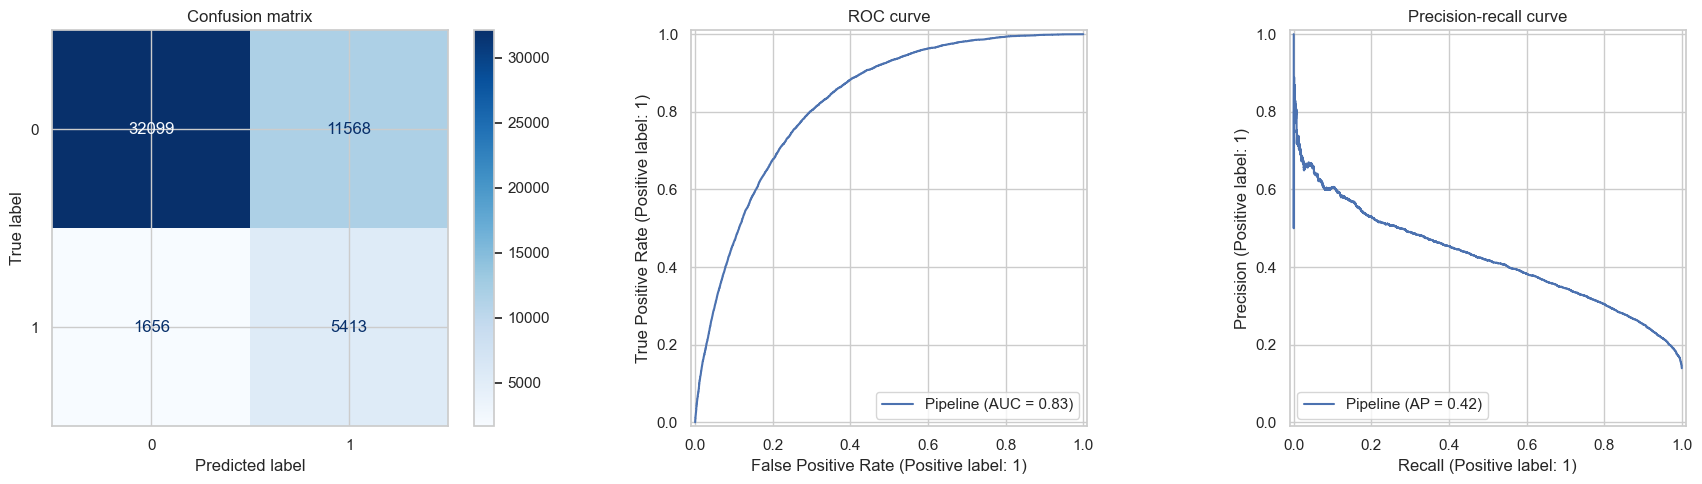

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion matrix")

RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=axes[1])
axes[1].set_title("ROC curve")

PrecisionRecallDisplay.from_estimator(best_pipeline, X_test, y_test, ax=axes[2])
axes[2].set_title("Precision-recall curve")

plt.tight_layout()
plt.show()


# 8. Model Interpretation <a id="8"></a>

We will interpret the selected model in two complementary ways:

- **Permutation importance** asks how much model performance drops when a feature is randomly shuffled. This works with the full pipeline and does not require model-specific assumptions.
- **SHAP** estimates how each feature pushes individual predictions higher or lower for the positive diabetes/prediabetes class.

In [31]:
from sklearn.inspection import permutation_importance

IMPORTANCE_SAMPLE_SIZE = 5_000

if len(X_test) > IMPORTANCE_SAMPLE_SIZE:
    X_importance = X_test.sample(IMPORTANCE_SAMPLE_SIZE, random_state=RANDOM_STATE)
    y_importance = y_test.loc[X_importance.index]
else:
    X_importance = X_test
    y_importance = y_test

importance_result = permutation_importance(
    best_pipeline,
    X_importance,
    y_importance,
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance_mean": importance_result.importances_mean,
        "importance_std": importance_result.importances_std,
    }
).sort_values("importance_mean", ascending=False)

importance_df.head(15)


,feature,importance_mean,importance_std
3,BMI,0.076040,0.003837
13,GenHlth,0.072435,0.005650
1,HighChol,0.027476,0.005886
0,HighBP,0.024269,0.007542
18,Age,0.023256,0.006068
10,HvyAlcoholConsump,0.008466,0.002119
2,CholCheck,0.004872,0.002058
20,Income,0.004371,0.000710
6,HeartDiseaseorAttack,0.003272,0.001367
16,DiffWalk,0.002105,0.001301


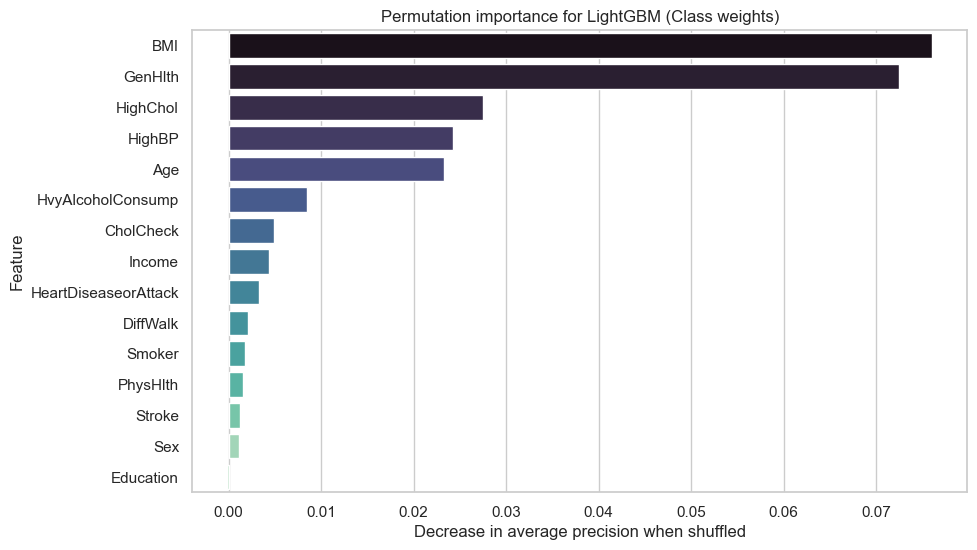

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="importance_mean", y="feature", palette="mako")
plt.title(f"Permutation importance for {best_model_name}")
plt.xlabel("Decrease in average precision when shuffled")
plt.ylabel("Feature")
plt.show()


Features near the top of the permutation importance chart have the largest effect on the selected model's ability to identify diabetes/prediabetes cases. For this dataset, health status indicators are expected to dominate, but demographic and socioeconomic features should be interpreted carefully because they may reflect structural differences in access, diagnosis, and risk exposure.


#### SHAP interpretation

Permutation importance gives a global performance-based ranking. SHAP gives a more detailed view of the selected model by estimating how each feature changes the predicted probability for individual test records.

To keep this step responsive, the SHAP explanation uses a sample of the test set.

In [40]:
import shap

SHAP_SAMPLE_SIZE = 1_000
SHAP_BACKGROUND_SIZE = 200

if len(X_test) > SHAP_SAMPLE_SIZE:
    X_shap_raw = X_test.sample(SHAP_SAMPLE_SIZE, random_state=RANDOM_STATE)
else:
    X_shap_raw = X_test.copy()

preprocessor_for_shap = best_pipeline.named_steps["preprocessor"]
model_for_shap = best_pipeline.named_steps["model"]
native_model_for_shap = getattr(model_for_shap, "model_", model_for_shap)

X_shap_processed = preprocessor_for_shap.transform(X_shap_raw)
if not isinstance(X_shap_processed, pd.DataFrame):
    X_shap_processed = pd.DataFrame(
        X_shap_processed,
        columns=preprocessor_for_shap.get_feature_names_out(),
        index=X_shap_raw.index,
    )

background_size = min(SHAP_BACKGROUND_SIZE, len(X_shap_processed))
shap_background = shap.sample(
    X_shap_processed,
    background_size,
    random_state=RANDOM_STATE,
)

tree_shap_supported_models = {
    "CatBoostClassifier",
    "DecisionTreeClassifier",
    "LGBMClassifier",
    "RandomForestClassifier",
    "XGBClassifier",
}

if native_model_for_shap.__class__.__name__ in tree_shap_supported_models:
    shap_explainer = shap.TreeExplainer(
        native_model_for_shap,
        data=shap_background,
        model_output="probability",
    )
    shap_values = shap_explainer(X_shap_processed)
else:
    def shap_predict_positive(processed_values):
        processed_df = pd.DataFrame(
            processed_values,
            columns=X_shap_processed.columns,
        )
        return model_for_shap.predict_proba(processed_df)[:, 1]

    shap_explainer = shap.Explainer(
        shap_predict_positive,
        shap_background,
        algorithm="permutation",
    )
    shap_values = shap_explainer(
        X_shap_processed,
        max_evals=2 * X_shap_processed.shape[1] + 1,
    )

shap_values_array = shap_values.values
shap_base_values = shap_values.base_values

if shap_values_array.ndim == 3:
    positive_class_index = 1
    shap_values_array = shap_values_array[:, :, positive_class_index]
    if np.ndim(shap_base_values) == 2:
        shap_base_values = shap_base_values[:, positive_class_index]

shap_values_positive = shap.Explanation(
    values=shap_values_array,
    base_values=shap_base_values,
    data=X_shap_processed.to_numpy(),
    feature_names=list(X_shap_processed.columns),
)

shap_importance_df = (
    pd.DataFrame(
        {
            "feature": X_shap_processed.columns,
            "mean_abs_shap": np.abs(shap_values_positive.values).mean(axis=0),
        }
    )
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

shap_importance_df.head(15)

,feature,mean_abs_shap
0,GenHlth,0.101988
1,Age,0.071773
2,BMI,0.067377
3,HighBP,0.061919
4,HighChol,0.049247
5,Sex,0.023952
6,Income,0.021283
7,HeartDiseaseorAttack,0.012505
8,CholCheck,0.011314
9,MentHlth,0.010898


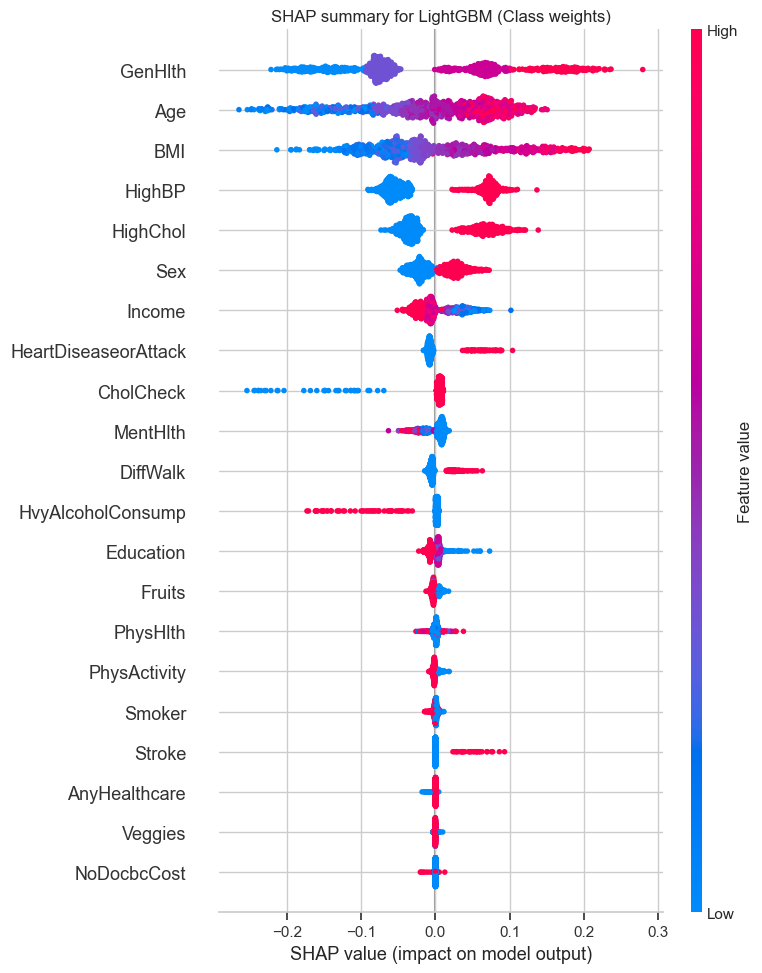

In [43]:
shap.plots.beeswarm(shap_values_positive, max_display=21, show=False)
plt.title(f"SHAP summary for {best_model_name}")
plt.tight_layout()
plt.show()

This SHAP (SHapley Additive Explanations) summary plot shows how each feature impacts the model's predictions.

How to understand this:

- x-axis (Impact on Model Output)
    - Negative values decrease the chance of predicting diabetes/prediabetes for the patient. 
    - Positive values increase the chance of predicting diabetes/prediabetes for the patient. 
- y-axis (Model Features)
    - The order of the features on the Y-axis is based on overall importance.
    - Color (Feature Value Intensity)
        - Red → Feature is at its higher range.
        - Blue → Feature is at its lower range.

#### Optional fairness check by sex

The dataset includes `Sex` as a binary feature. This quick check compares performance across the two recorded sex groups. A fuller fairness analysis would also inspect age, education, income, and intersections between these groups.


In [ ]:
subgroup_rows = []

for sex_value in sorted(X_test["Sex"].unique()):
    mask = X_test["Sex"] == sex_value
    mask_values = mask.to_numpy()
    subgroup_result = {
        "Sex": sex_value,
        "n": int(mask.sum()),
        "positive_rate": y_test.loc[mask].mean(),
    }
    subgroup_result.update(
        evaluate_predictions(
            y_test.loc[mask],
            y_pred_best[mask_values],
            y_score_best[mask_values],
        )
    )
    subgroup_rows.append(subgroup_result)

subgroup_results_df = pd.DataFrame(subgroup_rows)
subgroup_results_df


# 9. Results <a id="9"></a>

### Main takeaway

The best model should be selected using metrics that respect the project goal. For this dataset, average precision, recall, and ROC-AUC are more informative than accuracy because the positive class is much smaller than the negative class.

### Conclusions

- The dataset is large and has no missing values, which makes it convenient for supervised learning.
- The target is imbalanced, so a majority-class baseline is not useful even if its accuracy looks high.
- Health-related indicators such as general health, BMI, high blood pressure, high cholesterol, age, heart disease history, and walking difficulty are expected to be meaningful predictors.
- All available predictors are used in the final modeling workflow.
- XGBoost, LightGBM, CatBoost, and SMOTENC are evaluated as additional model/resampling candidates rather than assumed improvements.
- The hyperparameter tuning section tunes the top three cross-validation candidates and compares tuned vs. untuned holdout performance.
- Threshold tuning is important because the default `0.50` cutoff may not reflect the desired precision-recall tradeoff.

### Recommendations

- Use the model as a decision-support or educational tool, not as a clinical diagnosis system.
- Report recall, precision, ROC-AUC, average precision, and confusion matrices instead of accuracy alone.
- Keep SMOTENC only if it improves the metric that matters for the project, such as recall or F1, without unacceptable precision or average-precision loss.
- Keep tuned models only if they improve holdout performance compared with their untuned versions.
- Review subgroup performance before using model outputs in a health context.
- Validate the model on newer or local data before making policy or screening decisions.

### Future work

- Tune the classification threshold around a specific operational goal, such as high recall for screening.
- Tune XGBoost, LightGBM, CatBoost, and the SMOTENC sampling strategy more deeply if one of them looks promising.
- Compare a model with and without sensitive demographic/socioeconomic variables.
- Add calibration analysis so predicted probabilities are easier to interpret.

# 10. Save Model <a id="10"></a>

The selected pipeline includes both preprocessing and the trained classifier, so saving the pipeline is enough to reuse the model later.

In [ ]:
from pathlib import Path
import json
import joblib

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "cdc_diabetes_best_model.joblib"
metrics_path = models_dir / "cdc_diabetes_model_metrics.json"

joblib.dump(best_pipeline, model_path)

model_metrics = {
    "selected_model": best_model_name,
    "chosen_threshold": float(chosen_threshold),
    **evaluate_predictions(y_test, y_pred_thresholded, y_score_best),
}

metrics_path.write_text(json.dumps(model_metrics, indent=2))

print(f"Saved model to: {model_path}")
print(f"Saved metrics to: {metrics_path}")